### Problem Statement
In real-world data pipelines, failures can occur at any stage — network issues, service outages, or unexpected errors. Without a recovery mechanism, the entire pipeline restarts from scratch, wasting time and compute resources on steps that already succeeded.

- Usecase: Fault-Tolerant Content Publishing Pipeline with Checkpoint-Based Recovery

🗑️  Old DB cleared for fresh demo

🚀 RUN 1: Pipeline starts — will crash in translate node

Flow: fetch_data → validate → summarize → translate → publish


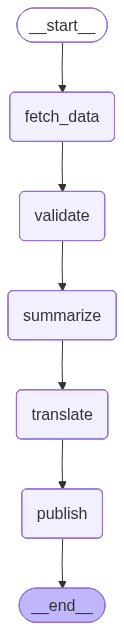


📥 [Node 1] fetch_data — STARTED
   Fetched data for topic: Artificial Intelligence
✅ [Node 1] fetch_data — COMPLETED → checkpoint saved

🔍 [Node 2] validate — STARTED
   Validation result: True
✅ [Node 2] validate — COMPLETED → checkpoint saved

📝 [Node 3] summarize — STARTED
   Summary created: Summary of 'Artificial Intelligence': Key insights extracted and condensed.
✅ [Node 3] summarize — COMPLETED → checkpoint saved

🌐 [Node 4] translate — STARTED
   💥 CRASH inside translate node!
   ❌ Node did NOT complete → checkpoint NOT saved for this node
   💾 Last saved checkpoint = after summarize (Node 3)

⛔ Pipeline failed: Translation service failed!

📊 CHECKPOINT STATE AFTER CRASH:
  ✅ Nodes completed : ['fetch_data', 'validate', 'summarize']
  ❌ Node that failed : translate  (not in completed list)
  📌 Next node to run : ('translate',)
  💾 raw_data saved  : 'Raw research data about 'Artificial Inte...'
  💾 summary saved   : 'Summary of 'Artificial Intelligence': Key insights extracted

In [ ]:
import time
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver
import os

# -----------------------------------------------------------
# State
# -----------------------------------------------------------
class PipelineState(TypedDict):
    topic: str
    raw_data: str
    is_valid: bool
    summary: str
    translated: str
    published: bool
    simulate_crash: bool        # flag to control crash
    completed_nodes: list[str]  # track which nodes ran

# -----------------------------------------------------------
# Node 1: Fetch Data
# -----------------------------------------------------------
def fetch_data(state: PipelineState) -> PipelineState:
    print("\n📥 [Node 1] fetch_data — STARTED")
    time.sleep(0.3)  # simulate work

    raw = f"Raw research data about '{state['topic']}': lots of content here..."
    
    print(f"   Fetched data for topic: {state['topic']}")
    print("✅ [Node 1] fetch_data — COMPLETED → checkpoint saved")

    return {
        **state,
        "raw_data": raw,
        "completed_nodes": state["completed_nodes"] + ["fetch_data"]
    }

# -----------------------------------------------------------
# Node 2: Validate
# -----------------------------------------------------------
def validate(state: PipelineState) -> PipelineState:
    print("\n🔍 [Node 2] validate — STARTED")
    time.sleep(0.3)

    is_valid = len(state["raw_data"]) > 10  # simple check

    print(f"   Validation result: {is_valid}")
    print("✅ [Node 2] validate — COMPLETED → checkpoint saved")

    return {
        **state,
        "is_valid": is_valid,
        "completed_nodes": state["completed_nodes"] + ["validate"]
    }

# -----------------------------------------------------------
# Node 3: Summarize
# -----------------------------------------------------------
def summarize(state: PipelineState) -> PipelineState:
    print("\n📝 [Node 3] summarize — STARTED")
    time.sleep(0.3)

    summary = f"Summary of '{state['topic']}': Key insights extracted and condensed."

    print(f"   Summary created: {summary}")
    print("✅ [Node 3] summarize — COMPLETED → checkpoint saved")

    return {
        **state,
        "summary": summary,
        "completed_nodes": state["completed_nodes"] + ["summarize"]
    }

# -----------------------------------------------------------
# Node 4: Translate  ← CRASH HAPPENS HERE
# -----------------------------------------------------------
def translate(state: PipelineState) -> PipelineState:
    print("\n🌐 [Node 4] translate — STARTED")
    time.sleep(0.3)

    # Simulate crash ONLY on first run
    if state["simulate_crash"]:
        print("   💥 CRASH inside translate node!")
        print("   ❌ Node did NOT complete → checkpoint NOT saved for this node")
        print("   💾 Last saved checkpoint = after summarize (Node 3)")
        raise RuntimeError("Translation service failed!")

    translated = f"[Translated] {state['summary']}"
    print(f"   Translated: {translated}")
    print("✅ [Node 4] translate — COMPLETED → checkpoint saved")

    return {
        **state,
        "translated": translated,
        "completed_nodes": state["completed_nodes"] + ["translate"]
    }

# -----------------------------------------------------------
# Node 5: Publish
# -----------------------------------------------------------
def publish(state: PipelineState) -> PipelineState:
    print("\n🚀 [Node 5] publish — STARTED")
    time.sleep(0.3)

    print(f"   Publishing: {state['translated']}")
    print("✅ [Node 5] publish — COMPLETED → checkpoint saved")

    return {
        **state,
        "published": True,
        "completed_nodes": state["completed_nodes"] + ["publish"]
    }

# -----------------------------------------------------------
# Build Graph
# -----------------------------------------------------------
builder = StateGraph(PipelineState)

builder.add_node("fetch_data", fetch_data)
builder.add_node("validate",   validate)
builder.add_node("summarize",  summarize)
builder.add_node("translate",  translate)
builder.add_node("publish",    publish)

builder.add_edge(START,        "fetch_data")
builder.add_edge("fetch_data", "validate")
builder.add_edge("validate",   "summarize")
builder.add_edge("summarize",  "translate")
builder.add_edge("translate",  "publish")
builder.add_edge("publish",     END)

# -----------------------------------------------------------
# Setup
# -----------------------------------------------------------
DB_PATH       = "pipeline.db"
THREAD_CONFIG = {"configurable": {"thread_id": "pipeline-job-001"}}

# Delete old DB to start fresh
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)
    print("🗑️  Old DB cleared for fresh demo\n")

# -----------------------------------------------------------
# RUN 1: Crashes inside translate node
# -----------------------------------------------------------
print("=" * 60)
print("🚀 RUN 1: Pipeline starts — will crash in translate node")
print("=" * 60)
print("\nFlow: fetch_data → validate → summarize → translate → publish")

with SqliteSaver.from_conn_string(DB_PATH) as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)
     # --- Print Graph ---
    try:
        from IPython.display import Image, display
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        # Fallback: print as text if not in Jupyter
        print(graph.get_graph().draw_mermaid())
    initial_state = {
        "topic":           "Artificial Intelligence",
        "raw_data":        "",
        "is_valid":        False,
        "summary":         "",
        "translated":      "",
        "published":       False,
        "simulate_crash":  True,       # trigger crash in translate
        "completed_nodes": [],
    }

    try:
        graph.invoke(initial_state, config=THREAD_CONFIG)

    except RuntimeError as e:
        print(f"\n⛔ Pipeline failed: {e}")

        # Show exactly where we are
        saved = graph.get_state(THREAD_CONFIG)

        print(f"\n{'='*60}")
        print(f"📊 CHECKPOINT STATE AFTER CRASH:")
        print(f"{'='*60}")
        print(f"  ✅ Nodes completed : {saved.values['completed_nodes']}")
        print(f"  ❌ Node that failed : translate  (not in completed list)")
        print(f"  📌 Next node to run : {saved.next}")
        print(f"  💾 raw_data saved  : '{saved.values['raw_data'][:40]}...'")
        print(f"  💾 summary saved   : '{saved.values['summary']}'")
        print(f"  💾 translated      : '{saved.values['translated']}' (empty — node failed)")

# -----------------------------------------------------------
# RUN 2: Resume — starts exactly from translate node
# -----------------------------------------------------------
print(f"\n{'='*60}")
print("🔄 RUN 2: Resuming pipeline from exact failure point")
print(f"{'='*60}")

with SqliteSaver.from_conn_string(DB_PATH) as checkpointer:
    graph = builder.compile(checkpointer=checkpointer)

    # Check what next node will be before resuming
    saved = graph.get_state(THREAD_CONFIG)
    print(f"\n📂 Loaded checkpoint:")
    print(f"   Already completed : {saved.values['completed_nodes']}")
    print(f"   ▶️  Will resume from : {saved.next}  ← exactly translate node")
    print(f"\n   NOTE: fetch_data, validate, summarize will NOT re-run")
    print(f"         Their results are loaded from checkpoint\n")

    # Fix simulate_crash = False so translate succeeds this time
    graph.update_state(
        THREAD_CONFIG,
        {"simulate_crash": False}
    )

    # Resume — None means "use checkpoint state, don't reinitialize"
    final = graph.invoke(None, config=THREAD_CONFIG)

    print(f"\n{'='*60}")
    print(f"🎉 PIPELINE COMPLETED SUCCESSFULLY")
    print(f"{'='*60}")
    print(f"  Nodes run in order : {final['completed_nodes']}")
    print(f"  Published          : {final['published']}")
    print(f"  Final output       : {final['translated']}")